In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import duckdb
import numpy as np
import polars as pl
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=2, palette=sns.color_palette('Set2'),)

from dafm import plots

In [3]:
duckdb.sql("""
attach '../runs.sqlite';
use runs;
""")

In [20]:
# KuramotoSivashinsky
# alt_ids = duckdb.sql(f"""
# select
#     alt_id, label, rng_seed, state_dimension, observe_every_n_time_steps
# from (
#     select Model.id, 'EnSF' as label from Model join ScoreMatchingMarginal on Model.id = ScoreMatchingMarginal.id where sampling_time_step_count = 20 and sampling_score_norm = 'LInfty'
#     union
#     select Model.id, 'EnFF-OT' as label from Model join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id join ConditionalOptimalTransport on FlowMatchingMarginal.DiffusionPath = ConditionalOptimalTransport.id join Local on FlowMatchingMarginal.EnergyGuidance = Local.id join Constant on Local.Schedule = Constant.id where sampling_time_step_count = 20 and sampler = 'EULER' and sigma_min = 0.01 and constant = 1.
#     union
#     select Model.id, 'EnFF-F2P' as label from Model join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id join PreviousPosteriorToPredictive on FlowMatchingMarginal.DiffusionPath = PreviousPosteriorToPredictive.id join Local on FlowMatchingMarginal.EnergyGuidance = Local.id join Constant on Local.Schedule = Constant.id where sampling_time_step_count = 20 and sampler = 'EULER' and sigma_min = 0.01 and constant = .2
#     union
#     select Model.id, 'EnKF-PO' as label from Model join EnsembleKalmanFilterPerturbedObservations on Model.id = EnsembleKalmanFilterPerturbedObservations.id join ConstantScale on Model.InflationScale = ConstantScale.id where constant = 1.0 and loc_radius_gc = 8.0
#     union
#     select Model.id, 'ESRF' as label from Model join EnsembleRandomizedSquareRootFilter on Model.id = EnsembleRandomizedSquareRootFilter.id join ConstantScale on Model.InflationScale = ConstantScale.id where constant = 1.0 and loc_radius_gc = 8.0
#     union
#     select Model.id, 'LETKF' as label from Model join LocalEnsembleTransformKalmanFilter on Model.id = LocalEnsembleTransformKalmanFilter.id join ConstantScale on Model.InflationScale = ConstantScale.id where constant = 1.0 and loc_radius_gc = 8.0
#     union
#     select Model.id, 'BPF' as label from Model join BootstrapParticleFilter on Model.id = BootstrapParticleFilter.id join ConstantScale on Model.InflationScale = ConstantScale.id where constant = 1.5
# ) as all_models
# join Conf on Conf.Model = all_models.id
# join Dataset on Conf.Dataset = Dataset.id
# join KuramotoSivashinsky on Dataset.id = KuramotoSivashinsky.id
# where state_dimension in (256, 512, 1024) and predicted_state_initial_condition_std = 1.0 and predicted_state_count = 20
# order by state_dimension, rng_seed, floating_point_precision, label
# """).pl()
# NavierStokes
alt_ids = duckdb.sql(f"""
select
    alt_id, label, rng_seed, state_dimension, observe_every_n_time_steps
from (
    select Model.id, 'EnSF' as label from Model join ScoreMatchingMarginal on Model.id = ScoreMatchingMarginal.id where sampling_time_step_count = 50 and sampling_score_norm = 'LInfty'
    union
    select Model.id, 'EnFF-OT' as label from Model join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id join ConditionalOptimalTransport on FlowMatchingMarginal.DiffusionPath = ConditionalOptimalTransport.id join Local on FlowMatchingMarginal.EnergyGuidance = Local.id join Constant on Local.Schedule = Constant.id where sampling_time_step_count = 50 and sampler = 'EULER' and sigma_min = 0.01 and constant = 1.
    union
    select Model.id, 'EnFF-F2P' as label from Model join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id join PreviousPosteriorToPredictive on FlowMatchingMarginal.DiffusionPath = PreviousPosteriorToPredictive.id join Local on FlowMatchingMarginal.EnergyGuidance = Local.id join Constant on Local.Schedule = Constant.id where sampling_time_step_count = 50 and sampler = 'EULER' and sigma_min = 0.01 and constant = .2
    union
    select Model.id, 'EnKF-PO' as label from Model join EnsembleKalmanFilterPerturbedObservations on Model.id = EnsembleKalmanFilterPerturbedObservations.id join ConstantScale on Model.InflationScale = ConstantScale.id where constant = 1.1 and loc_radius_gc = 8.0
    union
    select Model.id, 'ESRF' as label from Model join EnsembleRandomizedSquareRootFilter on Model.id = EnsembleRandomizedSquareRootFilter.id join ConstantScale on Model.InflationScale = ConstantScale.id where constant = 1.7 and loc_radius_gc = 8.0
    union
    select Model.id, 'LETKF' as label from Model join LocalEnsembleTransformKalmanFilter on Model.id = LocalEnsembleTransformKalmanFilter.id join ConstantScale on Model.InflationScale = ConstantScale.id where constant = 1.0 and loc_radius_gc = 6.0
) as all_models
join Conf on Conf.Model = all_models.id
join Dataset on Conf.Dataset = Dataset.id
join NavierStokes on Dataset.id = NavierStokes.id
where state_dimension in (3*10*10, 3*64*64, 3*256*256) and predicted_state_initial_condition_std = 1.0 and predicted_state_count = 20
order by state_dimension, rng_seed, label
""").pl()
alt_ids

alt_id,label,rng_seed,state_dimension,observe_every_n_time_steps
str,str,i64,i64,i64
"""rczq1tdn""","""ESRF""",97616566,300,10
"""8d3byc9t""","""EnFF-F2P""",97616566,300,10
"""0zs0oip9""","""EnFF-OT""",97616566,300,10
"""2wo3pfgp""","""EnKF-PO""",97616566,300,10
"""ub5lzq1y""","""EnSF""",97616566,300,10
…,…,…,…,…
"""v7o262ks""","""EnFF-F2P""",2376999025,196608,10
"""jerb4qqb""","""EnFF-OT""",2376999025,196608,10
"""10je262f""","""EnKF-PO""",2376999025,196608,10


In [21]:
duckdb.sql("""
set variable time_step_times_filepaths = (
    -- select list(format('/mnta/taosData/dafm/runs_sci_2025-05/{}/time_step_times.csv', alt_id)) from alt_ids
    select list(format('~/out/dafm/runs/{}/time_step_times.csv', alt_id)) from alt_ids
);
""")

In [22]:
time_step_times = duckdb.sql("""
select
    csvs.alt_id,
    label,
    rng_seed,
    state_dimension as Dimension,
    step,
    observe_every_n_time_steps,
    time_s as "Time (s)" from (
    select
        split(filename, '/')[-2] as alt_id,
        step,
        time_s
    from read_csv(getvariable(time_step_times_filepaths), filename=true, union_by_name=true)
) as csvs
join alt_ids on alt_ids.alt_id = csvs.alt_id
;
""").pl()
time_step_times

alt_id,label,rng_seed,Dimension,step,observe_every_n_time_steps,Time (s)
str,str,i64,i64,i64,i64,f64
"""rczq1tdn""","""ESRF""",97616566,300,1,10,0.122321
"""rczq1tdn""","""ESRF""",97616566,300,2,10,0.015293
"""rczq1tdn""","""ESRF""",97616566,300,3,10,0.015118
"""rczq1tdn""","""ESRF""",97616566,300,4,10,0.015153
"""rczq1tdn""","""ESRF""",97616566,300,5,10,0.016098
…,…,…,…,…,…,…
"""654x49tw""","""LETKF""",2376999025,196608,696,10,0.291901
"""654x49tw""","""LETKF""",2376999025,196608,697,10,0.308264
"""654x49tw""","""LETKF""",2376999025,196608,698,10,0.304864


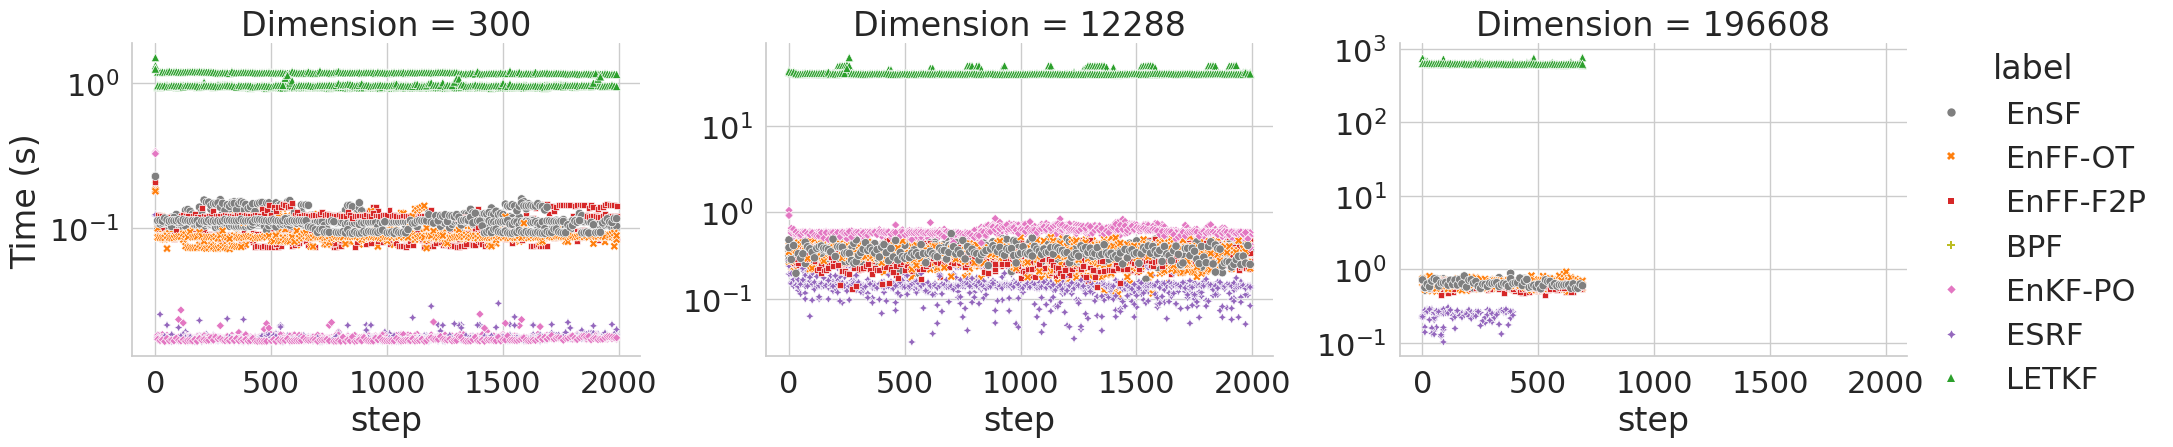

In [25]:
hue_order = ['EnSF', 'EnFF-OT', 'EnFF-F2P', 'BPF', 'EnKF-PO', 'ESRF', 'LETKF']
(
    sns.relplot(
        # kind='line',
        data=(
            time_step_times
            .filter(
                (pl.col('step') - 1) % pl.col('observe_every_n_time_steps') == 0
            )
        ),
        x='step',
        y='Time (s)',
        hue='label',
        style='label',
        hue_order=hue_order,
        style_order=hue_order,
        palette={
            'EnSF': 'tab:gray',
            'EnFF-OT': 'tab:orange',
            'EnFF-F2P': 'tab:red',
            'BPF': 'tab:olive',
            'EnKF-PO': 'tab:pink',
            'ESRF': 'tab:purple',
            'LETKF': 'tab:green',
        },
        col='Dimension',
        # markers=True,
        # markersize=10,
        aspect=1.3,
        facet_kws=dict(
            sharey=False,
        )
    )
    .set(
        yscale='log',
    )
)

shape: (80, 5)
┌──────────┬───────┬────────────┬───────────┬────────────┐
│ alt_id   ┆ label ┆ rng_seed   ┆ Dimension ┆ Time (s)   │
│ ---      ┆ ---   ┆ ---        ┆ ---       ┆ ---        │
│ str      ┆ str   ┆ i64        ┆ i64       ┆ f64        │
╞══════════╪═══════╪════════════╪═══════════╪════════════╡
│ fwjuq7e5 ┆ ESRF  ┆ 715319214  ┆ 300       ┆ 0.017743   │
│ 2jf245ua ┆ ESRF  ┆ 979497033  ┆ 300       ┆ 0.018109   │
│ fegeji7b ┆ ESRF  ┆ 2376999025 ┆ 300       ┆ 0.018232   │
│ 1db9vtsd ┆ ESRF  ┆ 462133975  ┆ 300       ┆ 0.018215   │
│ rczq1tdn ┆ ESRF  ┆ 97616566   ┆ 300       ┆ 0.018122   │
│ …        ┆ …     ┆ …          ┆ …         ┆ …          │
│ o3ii1lk4 ┆ LETKF ┆ 979497033  ┆ 196608    ┆ 623.151722 │
│ 654x49tw ┆ LETKF ┆ 2376999025 ┆ 196608    ┆ 626.121687 │
│ cudxqnku ┆ LETKF ┆ 97616566   ┆ 196608    ┆ 622.191023 │
│ gzxmdtww ┆ LETKF ┆ 715319214  ┆ 196608    ┆ 630.865733 │
│ mxfpb6g8 ┆ LETKF ┆ 462133975  ┆ 196608    ┆ 620.3993   │
└──────────┴───────┴────────────┴────────

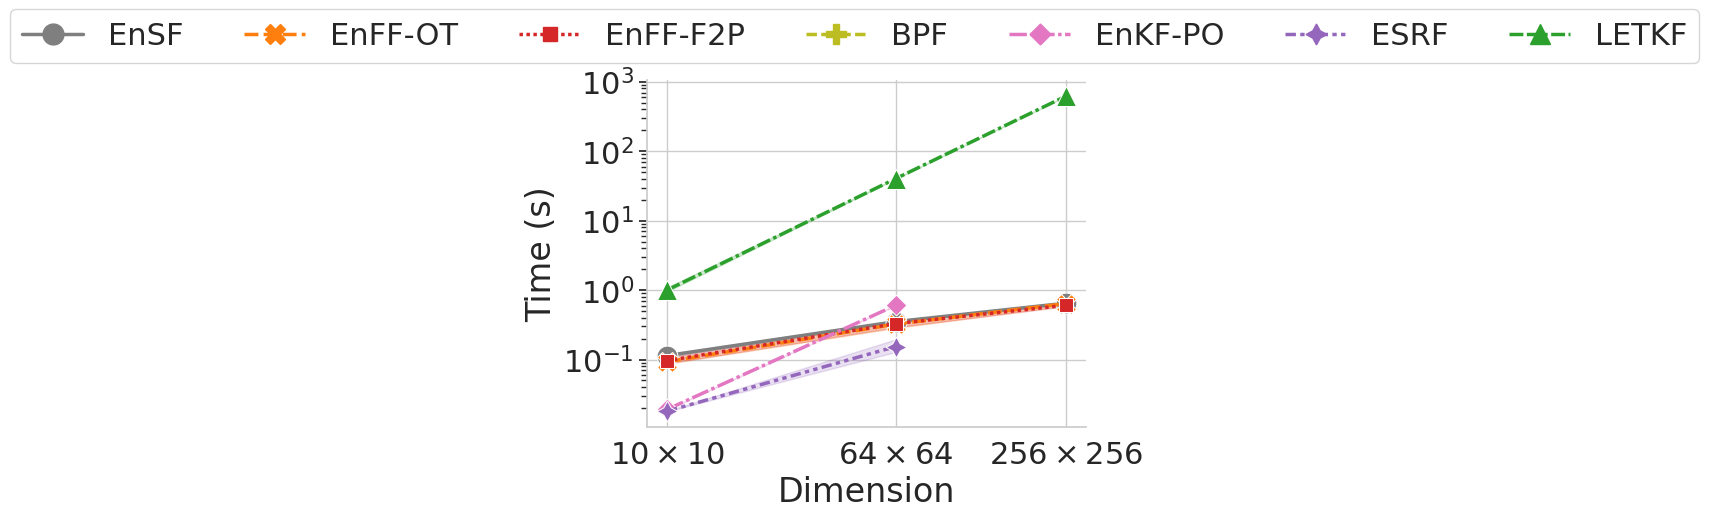

In [27]:
hue_order = ['EnSF', 'EnFF-OT', 'EnFF-F2P', 'BPF', 'EnKF-PO', 'ESRF', 'LETKF']
data = (
    time_step_times
    .filter(
        (pl.col('step') - 1) % pl.col('observe_every_n_time_steps') == 0,
    )
    .filter(
        ((pl.col('label') == 'ESRF') & (pl.col('Dimension') == 3*256*256)).not_(),
    )
    .group_by('alt_id', 'label', 'rng_seed', 'Dimension')
    .agg(pl.col('Time (s)').mean())
    .sort('label', 'Dimension')
)
xticks = data.select(pl.col('Dimension').unique()).to_numpy().squeeze()
xticklabels = xticks
xticklabels = [rf'${int(x)} \times {int(x)}$' for x in np.sqrt(xticks / 3)]
print(data)
plot_times = (
    sns.relplot(
        kind='line',
        data=data,
        x='Dimension',
        y='Time (s)',
        hue='label',
        style='label',
        hue_order=hue_order,
        style_order=hue_order,
        palette={
            'EnSF': 'tab:gray',
            'EnFF-OT': 'tab:orange',
            'EnFF-F2P': 'tab:red',
            'BPF': 'tab:olive',
            'EnKF-PO': 'tab:pink',
            'ESRF': 'tab:purple',
            'LETKF': 'tab:green',
        },
        markers=True,
        markersize=15,
        linewidth=2.5,
        aspect=1.3,
    )
    .set(
        xscale='log',
        yscale='log',
        xticks=xticks,
        xticklabels=xticklabels,
    )
)
ax_twin = plot_times.axes[0][0].twinx()
ax_twin.set_axis_off()
sns.move_legend(
    plot_times,
    loc='upper center',
    ncol=len(hue_order),
    title='',
    bbox_to_anchor=(.455, 1.10),
    frameon=True,
    fancybox=True,
)
for (row, col, hue), _ in plot_times.facet_data():
    ax = plot_times.axes[row][col]
    ax.xaxis.minorticks_off()

In [28]:
plots.save_all_subfigures(plot_times, 'TimeByDimension')

In [ ]:
table = (
    data
    .group_by('label', 'Sampling timesteps')
    .agg(
        pl.col('Time (s)').mean().alias('Time mean (s)'),
        pl.col('Time (s)').std(ddof=0).alias('Time std. (s)'),
    )
    .select(
        # pl.format('{} {}', pl.col('label'), pl.col('Sampling timesteps')).alias('Model'),
        pl.col('label').alias('Model'),
        pl.col('Sampling timesteps').alias('$T$'),
        # (pl.col('label') + ' (' + pl.col('Sampling timesteps').cast(str) + ')').alias('Model'),
        pl.format(
            r'${}_{{\pm {}}}$',
            pl.col('Time mean (s)').map_elements(lambda x: f'{x:.3f}', return_dtype=str),
            pl.col('Time std. (s)').map_elements(lambda x: f'{x:.3f}', return_dtype=str),
        ).alias('Time (s)'),
    )
    .sort('Model')
)
table

In [ ]:
print(table.to_pandas().to_latex(index=False))

In [ ]:
plots.save_all_subfigures(plot_times, 'ExecutionTimeSum')

In [ ]:
alt_id_to_label = {
    # Lorenz96Bao2024EnSF
    # 'uha1a304': 'EnSF',  # sampling_time_step_count=10 rng_seed=462133975
    # 'xp29tge5': 'EnFF-OT',  # sampling_time_step_count=10 rng_seed=462133975
    # '9fastxa9': 'EnSF',  # sampling_time_step_count=20 rng_seed=462133975
    # 'dexfbenv': 'EnFF-OT',  # sampling_time_step_count=20 rng_seed=462133975
    # 'nqbpry75': 'EnSF',  # sampling_time_step_count=50 rng_seed=462133975
    # 'q3lihp2g': 'EnFF-OT',  # sampling_time_step_count=50 rng_seed=462133975
    # '1xvp5lig': 'EnSF',  # sampling_time_step_count=10 rng_seed=2376999025
    # 'eriikp1u': 'EnFF-OT',  # sampling_time_step_count=10 rng_seed=2376999025
    # 'pkwvt6gk': 'EnSF',  # sampling_time_step_count=20 rng_seed=2376999025
    # '7igtkq4a': 'EnFF-OT',  # sampling_time_step_count=20 rng_seed=2376999025
    # 'yq1eaqxr': 'EnSF',  # sampling_time_step_count=50 rng_seed=2376999025
    # 'h8l7xw8q': 'EnFF-OT',  # sampling_time_step_count=50 rng_seed=2376999025

    # NavierStokesDim64
    # 'sfsy27vc': 'EnSF',  # sampling_time_step_count=20 rng_seed=97616566
    # 'f9908g7m': 'EnFF-OT',  # sampling_time_step_count=20 rng_seed=97616566
    # '4f0eg86z': 'EnSF',  # sampling_time_step_count=50 rng_seed=97616566
    # '2w2rwf0c': 'EnFF-OT',  # sampling_time_step_count=50 rng_seed=97616566
    # '7vww91h3': 'EnSF',  # sampling_time_step_count=20 rng_seed=462133975
    # 'qgmlcthg': 'EnFF-OT',  # sampling_time_step_count=20 rng_seed=462133975
    # 'fk708dzr': 'EnSF',  # sampling_time_step_count=50 rng_seed=462133975
    # 'p1nvic4f': 'EnFF-OT',  # sampling_time_step_count=50 rng_seed=462133975
    # 'pdcrol0s': 'EnSF',  # sampling_time_step_count=20 rng_seed=715319214
    # 'dhg0w990': 'EnFF-OT',  # sampling_time_step_count=20 rng_seed=715319214
    # '0mgoi1k6': 'EnSF',  # sampling_time_step_count=50 rng_seed=715319214
    # 'daobe0dl': 'EnFF-OT',  # sampling_time_step_count=50 rng_seed=715319214
    # 'w4tlx0pw': 'EnSF',  # sampling_time_step_count=20 rng_seed=979497033
    # '0d280i72': 'EnFF-OT',  # sampling_time_step_count=20 rng_seed=979497033
    # 'qj161jfx': 'EnSF',  # sampling_time_step_count=50 rng_seed=979497033
    # '6oapd3dk': 'EnFF-OT',  # sampling_time_step_count=50 rng_seed=979497033
    # 'cfbwxnup': 'EnFF-OT',  # sampling_time_step_count=10 rng_seed=2376999025
    # 'c2f2fz7j': 'EnSF',  # sampling_time_step_count=20 rng_seed=2376999025
    # 'eijvq9xb': 'EnFF-OT',  # sampling_time_step_count=20 rng_seed=2376999025
    # 'vpcuhvjp': 'EnSF',  # sampling_time_step_count=50 rng_seed=2376999025
    # 'fdyt2eb3': 'EnFF-OT',  # sampling_time_step_count=50 rng_seed=2376999025
    
    # NavierStokesDim256
    # '4jkvp3sd': 'EnFF-OT',  # sampling_time_step_count=20 rng_seed=97616566
    # 'y68jj7ko': 'EnSF',  # sampling_time_step_count=50 rng_seed=97616566
    # 'bmqxrqdh': 'EnFF-OT',  # sampling_time_step_count=50 rng_seed=97616566
    # '9wgb8epw': 'EnFF-OT',  # sampling_time_step_count=20 rng_seed=462133975
    # 'u38vggmy': 'EnFF-OT',  # sampling_time_step_count=20 rng_seed=715319214
    # 'z19i455i': 'EnSF',  # sampling_time_step_count=50 rng_seed=715319214
    # '5561y8s3': 'EnFF-OT',  # sampling_time_step_count=50 rng_seed=715319214
    # 'imfy6pzi': 'EnFF-OT',  # sampling_time_step_count=20 rng_seed=979497033
    # 'in7i7zwn': 'EnFF-OT',  # sampling_time_step_count=20 rng_seed=2376999025
    # 'uoc15dkh': 'EnSF',  # sampling_time_step_count=50 rng_seed=2376999025
    # 'jerb4qqb': 'EnFF-OT',  # sampling_time_step_count=50 rng_seed=2376999025

    # KuramotoSivashinsky
    # '3k2gte7o': 'EnSF',  # sampling_time_step_count=10 rng_seed=97616566
    # 'r0x03bpn': 'EnFF-OT',  # sampling_time_step_count=10 rng_seed=97616566
    # 'dpay746j': 'EnSF',  # sampling_time_step_count=20 rng_seed=97616566
    # 'r6j7mz7t': 'EnFF-OT',  # sampling_time_step_count=20 rng_seed=97616566
    # 'rsykevhy': 'EnSF',  # sampling_time_step_count=50 rng_seed=97616566
    # '1s790g5z': 'EnFF-OT',  # sampling_time_step_count=50 rng_seed=97616566
    # 'la8cajc1': 'EnSF',  # sampling_time_step_count=10 rng_seed=462133975
    # 'g671jhti': 'EnFF-OT',  # sampling_time_step_count=10 rng_seed=462133975
    # 'as4tbkeo': 'EnSF',  # sampling_time_step_count=20 rng_seed=462133975
    # 'k8usyldj': 'EnFF-OT',  # sampling_time_step_count=20 rng_seed=462133975
    # 'h3rgu5rf': 'EnSF',  # sampling_time_step_count=50 rng_seed=462133975
    # 'ktvdxqq6': 'EnFF-OT',  # sampling_time_step_count=50 rng_seed=462133975
    # 'mhvfqefv': 'EnSF',  # sampling_time_step_count=10 rng_seed=715319214
    # 'uevs40qo': 'EnFF-OT',  # sampling_time_step_count=10 rng_seed=715319214
    # 'dsmyu7gu': 'EnSF',  # sampling_time_step_count=20 rng_seed=715319214
    # '71qimf5i': 'EnFF-OT',  # sampling_time_step_count=20 rng_seed=715319214
    # 'b1x9phjs': 'EnSF',  # sampling_time_step_count=50 rng_seed=715319214
    # '4bcjvj74': 'EnFF-OT',  # sampling_time_step_count=50 rng_seed=715319214
    # '6pd7d6zp': 'EnSF',  # sampling_time_step_count=10 rng_seed=979497033
    # 'g9d5c2af': 'EnFF-OT',  # sampling_time_step_count=10 rng_seed=979497033
    # 'lzm4recz': 'EnSF',  # sampling_time_step_count=20 rng_seed=979497033
    # 'myod1mnu': 'EnFF-OT',  # sampling_time_step_count=20 rng_seed=979497033
    # 'e1bw0o3j': 'EnSF',  # sampling_time_step_count=50 rng_seed=979497033
    # 'erilhzbx': 'EnFF-OT',  # sampling_time_step_count=50 rng_seed=979497033
    # 'dwrinhfi': 'EnSF',  # sampling_time_step_count=10 rng_seed=2376999025
    # 'ic8igmlg': 'EnFF-OT',  # sampling_time_step_count=10 rng_seed=2376999025
    # 'glis0of9': 'EnSF',  # sampling_time_step_count=20 rng_seed=2376999025
    # '1h275uvu': 'EnFF-OT',  # sampling_time_step_count=20 rng_seed=2376999025
    # 'wpp5ymyl': 'EnSF',  # sampling_time_step_count=50 rng_seed=2376999025
    # 'fje0w213': 'EnFF-OT',  # sampling_time_step_count=50 rng_seed=2376999025

    # NavierStokesDim64 PreviousPosteriorToPredictive
    # 'm75cimjb': 'EnFF-F2P',  # sampling_time_step_count=10 rng_seed=97616566
    # 'spewsmgu': 'EnFF-F2P',  # sampling_time_step_count=20 rng_seed=97616566
    # '75oao6rf': 'EnFF-F2P',  # sampling_time_step_count=50 rng_seed=97616566
    # 'npkp5k4u': 'EnFF-F2P',  # sampling_time_step_count=10 rng_seed=462133975
    # 'dq180in7': 'EnFF-F2P',  # sampling_time_step_count=20 rng_seed=462133975
    # 'pzwc53an': 'EnFF-F2P',  # sampling_time_step_count=50 rng_seed=462133975
    # 'k6kkl9z0': 'EnFF-F2P',  # sampling_time_step_count=10 rng_seed=715319214
    # 'tua46s6u': 'EnFF-F2P',  # sampling_time_step_count=20 rng_seed=715319214
    # 'xr6f99s4': 'EnFF-F2P',  # sampling_time_step_count=50 rng_seed=715319214
    # '9h940l2f': 'EnFF-F2P',  # sampling_time_step_count=10 rng_seed=979497033
    # '0cxggpuh': 'EnFF-F2P',  # sampling_time_step_count=20 rng_seed=979497033
    # '5vcae2j7': 'EnFF-F2P',  # sampling_time_step_count=50 rng_seed=979497033
    # 'a90ztq4d': 'EnFF-F2P',  # sampling_time_step_count=10 rng_seed=2376999025
    # 'lnlhx2nw': 'EnFF-F2P',  # sampling_time_step_count=20 rng_seed=2376999025
    # 'ji3tlesm': 'EnFF-F2P',  # sampling_time_step_count=50 rng_seed=2376999025

    # NavierStokesDim256 PreviousPosteriorToPredictive
    '0s3x2ehk': 'EnFF-F2P',  # sampling_time_step_count=10 rng_seed=97616566
    'qr1rvovz': 'EnFF-F2P',  # sampling_time_step_count=20 rng_seed=97616566
    'iron71a3': 'EnFF-F2P',  # sampling_time_step_count=50 rng_seed=97616566
    'qgq9n9yo': 'EnFF-F2P',  # sampling_time_step_count=10 rng_seed=462133975
    'etni5q5g': 'EnFF-F2P',  # sampling_time_step_count=20 rng_seed=462133975
    'nfgiet6j': 'EnFF-F2P',  # sampling_time_step_count=50 rng_seed=462133975
    'x85k4a6u': 'EnFF-F2P',  # sampling_time_step_count=10 rng_seed=715319214
    'l287grw5': 'EnFF-F2P',  # sampling_time_step_count=20 rng_seed=715319214
    'lfvmmeks': 'EnFF-F2P',  # sampling_time_step_count=50 rng_seed=715319214
    '8wxywvq1': 'EnFF-F2P',  # sampling_time_step_count=10 rng_seed=979497033
    'pk5jyel5': 'EnFF-F2P',  # sampling_time_step_count=20 rng_seed=979497033
    'l6lbnkg1': 'EnFF-F2P',  # sampling_time_step_count=50 rng_seed=979497033
    'i2m9dq0f': 'EnFF-F2P',  # sampling_time_step_count=10 rng_seed=2376999025
    'l8djiv5j': 'EnFF-F2P',  # sampling_time_step_count=20 rng_seed=2376999025
    'v7o262ks': 'EnFF-F2P',  # sampling_time_step_count=50 rng_seed=2376999025

    # KuramotoSivashinsky PreviousPosteriorToPredictive
    # 'fq9sdx9f': 'EnFF-F2P',  # sampling_time_step_count=10 rng_seed=97616566
    # 'wkvgbys9': 'EnFF-F2P',  # sampling_time_step_count=20 rng_seed=97616566
    # '2xdhzafp': 'EnFF-F2P',  # sampling_time_step_count=50 rng_seed=97616566
    # 'm9zmus7p': 'EnFF-F2P',  # sampling_time_step_count=10 rng_seed=462133975
    # '0600f8vv': 'EnFF-F2P',  # sampling_time_step_count=20 rng_seed=462133975
    # 'vamm4j8p': 'EnFF-F2P',  # sampling_time_step_count=50 rng_seed=462133975
    # '62bkbma1': 'EnFF-F2P',  # sampling_time_step_count=10 rng_seed=715319214
    # 'k0iiku1q': 'EnFF-F2P',  # sampling_time_step_count=20 rng_seed=715319214
    # 'hai0e76r': 'EnFF-F2P',  # sampling_time_step_count=50 rng_seed=715319214
    # 's19j1x87': 'EnFF-F2P',  # sampling_time_step_count=10 rng_seed=979497033
    # '3oktgwpx': 'EnFF-F2P',  # sampling_time_step_count=20 rng_seed=979497033
    # 'dolqeooq': 'EnFF-F2P',  # sampling_time_step_count=50 rng_seed=979497033
    # 'k1m5imyz': 'EnFF-F2P',  # sampling_time_step_count=10 rng_seed=2376999025
    # 'j5g9p5ni': 'EnFF-F2P',  # sampling_time_step_count=20 rng_seed=2376999025
    # 'qyw7f65x': 'EnFF-F2P',  # sampling_time_step_count=50 rng_seed=2376999025
}
alt_ids = pl.DataFrame(list(alt_id_to_label.items()), schema=['alt_id', 'label'], orient='row')
alt_ids